# 🩻 Chest X-Ray Pneumonia Detection Using Deep Learning

## 📌 Project Overview

This project focuses on detecting Pneumonia from Chest X-Ray images using Deep Learning and Transfer Learning techniques.

The notebook is divided into multiple stages:

1. Base CNN Model
2. Advanced CNN Model
3. EfficientNetB0 Transfer Learning
4. ResNet50V2 Transfer Learning
5. Final Model Comparison

---

## 🎯 Objectives

- Learn CNN fundamentals
- Understand optimization techniques
- Explore Transfer Learning
- Compare multiple architectures
- Evaluate medical image classification performance

---

## 🛠️ Technologies Used

- Python
- TensorFlow / Keras
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-Learn

---

## 📂 Dataset

Dataset: Chest X-Ray Pneumonia Dataset

Classes:
- NORMAL
- PNEUMONIA

---

## 🚀 Workflow

Data Loading → Preprocessing → Model Training → Evaluation → Comparison → Final Prediction

# 📦 Import Libraries

This section imports all required libraries for:
- Deep Learning
- Visualization
- Evaluation
- Transfer Learning
- Optimization

In [1]:
# ======================================
# BASIC LIBRARIES
# ======================================

import os
import gc
import random
import warnings

# ======================================
# NUMERICAL COMPUTATION
# ======================================

import numpy as np
import pandas as pd

# ======================================
# VISUALIZATION
# ======================================

import matplotlib.pyplot as plt
import seaborn as sns

# ======================================
# MACHINE LEARNING METRICS
# ======================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# ======================================
# DEEP LEARNING
# ======================================

import tensorflow as tf

from tensorflow.keras import mixed_precision
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization,
    GlobalAveragePooling2D,
    SeparableConv2D,
    InputLayer
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings("ignore")

In [2]:
import kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


# ⚙️ Project Configuration

This section contains:
- image size
- batch size
- epochs
- learning rate
- dataset path

Using a configuration section improves:
- readability
- maintainability
- debugging

In [3]:
# ======================================
# PROJECT CONFIGURATION
# ======================================

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 1e-4

DATASET_PATH = "/content/chest_xray"

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]

In [4]:
# ======================================
# ENABLE MIXED PRECISION
# ======================================

mixed_precision.set_global_policy('mixed_float16')

# ======================================
# CHECK GPU
# ======================================

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# set path
base_path = os.path.join(path, 'chest_xray')
train_path = os.path.join(base_path, 'train')
test_path = os.path.join(base_path, 'test')
val_path = os.path.join(base_path, 'val')

In [6]:
print(os.listdir(base_path))

['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [7]:
print("Train files:", len(os.listdir(train_path)))
print("Test files:", len(os.listdir(test_path)))
print("Val files:", len(os.listdir(val_path)))


print("Total files:", len(os.listdir(train_path))
                           + len(os.listdir(test_path))
                           + len(os.listdir(val_path))
                                )


Train files: 2
Test files: 2
Val files: 2
Total files: 6


In [8]:
images = ['NORMAL', 'PNEUMONIA']
for i in images:
  print(f"Total {i} images :{len(os.listdir(os.path.join(train_path, i)))}")

Total NORMAL images :1341
Total PNEUMONIA images :3875


# 📂 Dataset Loading

The dataset is loaded using:
`image_dataset_from_directory()`

This creates optimized TensorFlow datasets directly from folder structure.

In [9]:
# ======================================
# TRAIN DATASET
# ======================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="binary",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

# ======================================
# VALIDATION DATASET
# ======================================

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    labels="inferred",
    label_mode="binary",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ======================================
# TEST DATASET
# ======================================

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    labels="inferred",
    label_mode="binary",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)


# check classes
class_names = train_ds.class_names
print(class_names)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
['NORMAL', 'PNEUMONIA']


# ⚡ Dataset Optimization

This section improves training speed using:
- cache()
- prefetch()
- AUTOTUNE

These optimizations reduce GPU waiting time and improve Colab performance.

In [10]:
# ======================================
# AUTOTUNE
# ======================================

AUTOTUNE = tf.data.AUTOTUNE

# ======================================
# OPTIMIZE DATA PIPELINE
# ======================================

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)

val_ds = val_ds.cache().prefetch(AUTOTUNE)

test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [11]:
# Count total train images
train_counts = []

for label in ['NORMAL', 'PNEUMONIA']:
  count = len(os.listdir(os.path.join(train_path, label)))
  train_counts.append(count)

print(train_counts)

[1341, 3875]


# 🖼️ Dataset Visualization

Visualizing sample images helps verify:
- labels
- image quality
- preprocessing correctness

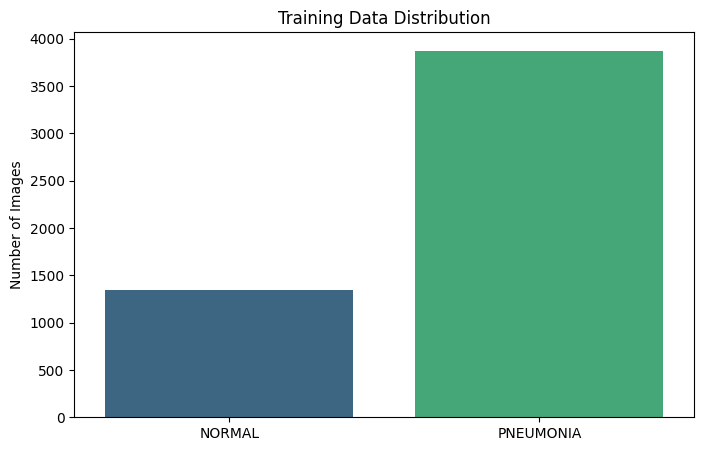

Normal images: 1341
Pneumonia images: 3875


In [12]:
# Visualization
plt.figure(figsize = (8,5))
sns.barplot(x=['NORMAL', 'PNEUMONIA'], y=train_counts, palette='viridis')
plt.title('Training Data Distribution')
plt.ylabel('Number of Images')
plt.show()

print(f"Normal images: {train_counts[0]}")
print(f"Pneumonia images: {train_counts[1]}")

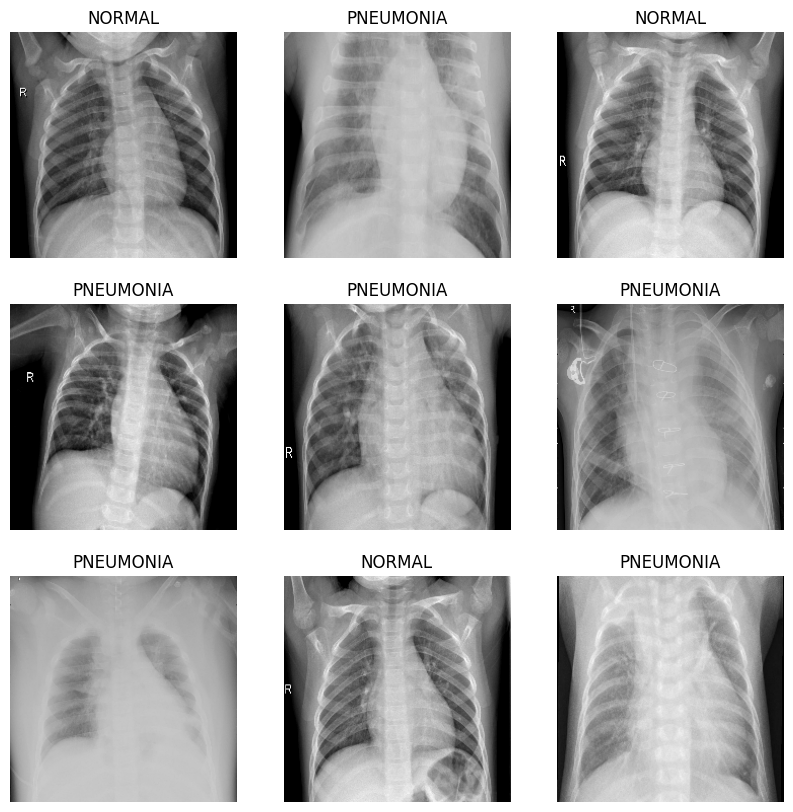

In [13]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(CLASS_NAMES[int(labels[i])])

        plt.axis("off")

plt.show()

# 🤖 Base CNN Model

This is the foundational CNN model.

Goals:
- Understand CNN basics
- Learn convolution & pooling
- Observe overfitting behavior
- Build basic image classification pipeline

In [14]:
# ======================================
# BUILD BASE CNN MODEL
# ======================================

base_model = Sequential([

    # INPUT LAYER
    InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),

    # FIRST CONV BLOCK
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),

    # SECOND CONV BLOCK
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),

    # THIRD CONV BLOCK
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D(pool_size=(2,2)),

    # CLASSIFIER
    GlobalAveragePooling2D(),

    Dropout(0.3),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(1, activation='sigmoid', dtype='float32')

])

base_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
# ======================================
# COMPILE MODEL
# ======================================

base_model.compile(

    optimizer=Adam(learning_rate=LEARNING_RATE),

    loss='binary_crossentropy',

    metrics=[
        'accuracy'
    ]
)

In [16]:
# ======================================
# CALLBACKS
# ======================================

callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        verbose=1
    ),

    ModelCheckpoint(
        filepath='best_base_model.keras',
        monitor='val_loss',
        save_best_only=True
    )

]

In [17]:
# ======================================
# TRAIN MODEL
# ======================================

history_base = base_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    callbacks=callbacks

)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 31s 56ms/step - accuracy: 0.8409 - loss: 0.3635 - val_accuracy: 0.5625 - val_loss: 0.9055 - learning_rate: 1.0000e-04
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.8923 - loss: 0.2563 - val_accuracy: 0.6250 - val_loss: 0.7930 - learning_rate: 1.0000e-04
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.9047 - loss: 0.2357 - val_accuracy: 0.5625 - val_loss: 1.3166 - learning_rate: 1.0000e-04
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9190 - loss: 0.2060
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9170 - loss: 0.2111 - val_accuracy: 0.6250 - val_loss: 0.8186 - learning_rate: 1.0000e-04
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9222 - loss: 0.1997 - val_accuracy: 0.5625 - val_loss: 1.2159 - learning_rate: 2.0000e-05
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accur

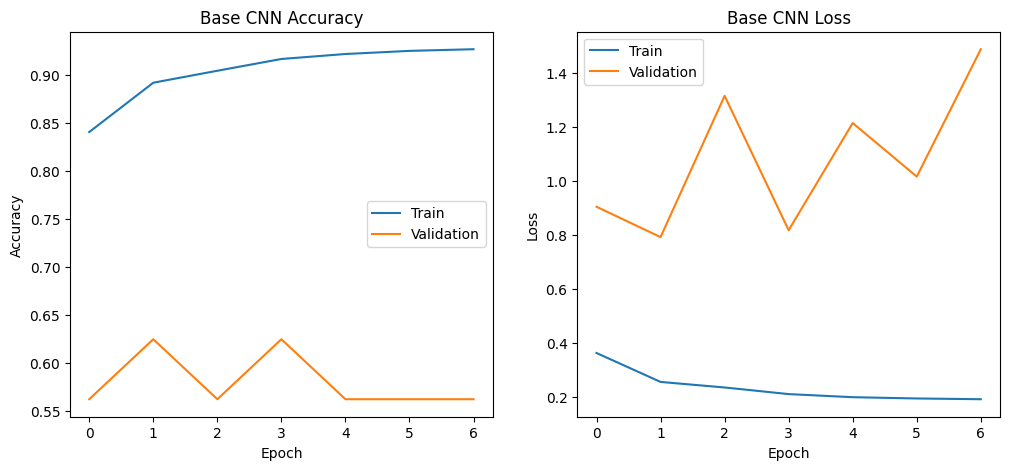

In [18]:
# ======================================
# PLOT TRAINING HISTORY
# ======================================

def plot_history(history, title):

    plt.figure(figsize=(12,5))

    # ACCURACY
    plt.subplot(1,2,1)

    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])

    plt.title(f'{title} Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')

    plt.legend(['Train','Validation'])

    # LOSS
    plt.subplot(1,2,2)

    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])

    plt.title(f'{title} Loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')

    plt.legend(['Train','Validation'])

    plt.show()

plot_history(history_base, "Base CNN")

In [19]:
# ======================================
# PREDICTIONS
# ======================================

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = base_model.predict(images)

    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy())

    y_pred.extend(predictions.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step


In [20]:
print(classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES
))

              precision    recall  f1-score   support

      NORMAL       0.82      0.66      0.73       234
   PNEUMONIA       0.82      0.91      0.86       390

    accuracy                           0.82       624
   macro avg       0.82      0.79      0.80       624
weighted avg       0.82      0.82      0.81       624



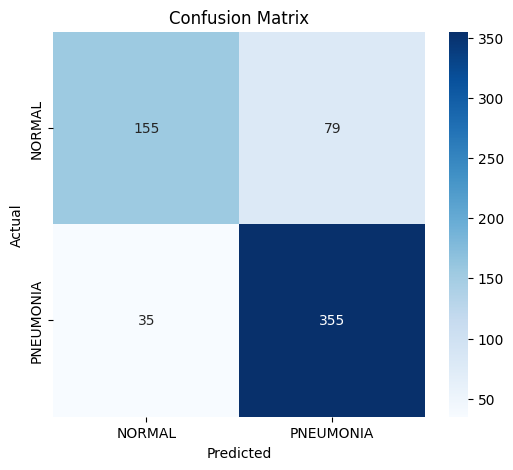

In [21]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


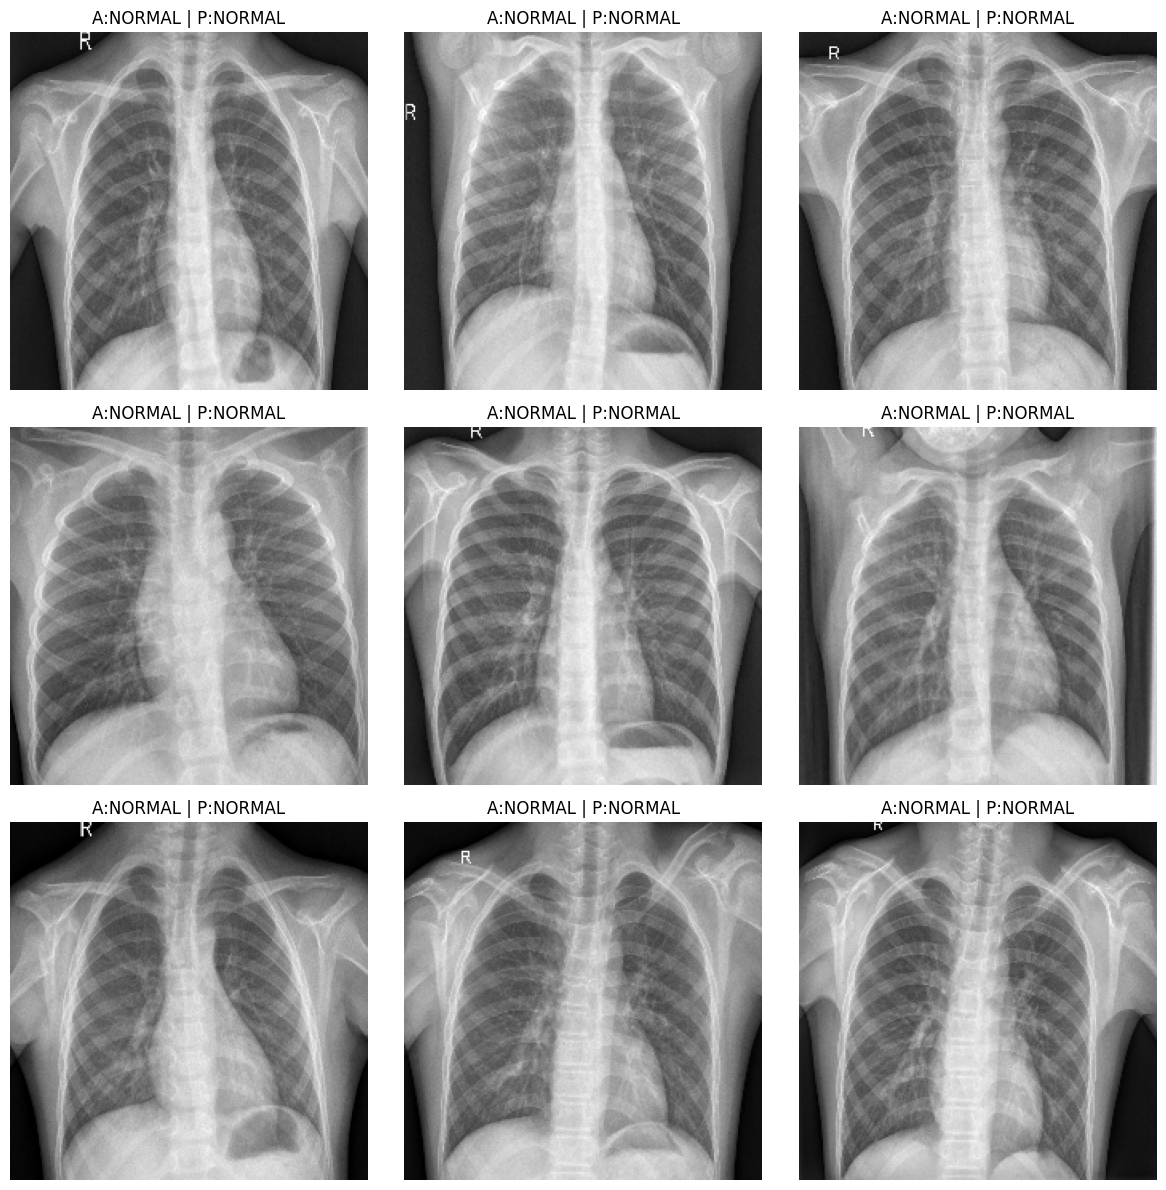

In [22]:
# ======================================
# VISUALIZE PREDICTIONS
# ======================================

plt.figure(figsize=(12,12))

for images, labels in test_ds.take(1):

    predictions = base_model.predict(images)

    predictions = (predictions > 0.5).astype(int)

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        actual = CLASS_NAMES[int(labels[i])]
        predicted = CLASS_NAMES[int(predictions[i])]

        plt.title(f"A:{actual} | P:{predicted}")

        plt.axis("off")

plt.tight_layout()
plt.show()

In [23]:
# ======================================
# CLEAR MEMORY
# ======================================

tf.keras.backend.clear_session()

gc.collect()

0

# 🚀 Advanced CNN Model

This model introduces:
- Data Augmentation
- Separable Convolutions
- Better Regularization
- Improved Optimization

Goal:
Build a stronger and more generalized CNN model.

In [24]:
# ======================================
# DATA AUGMENTATION
# ======================================

data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip("horizontal"),

    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.RandomZoom(0.1),

    tf.keras.layers.RandomContrast(0.1)

])

In [25]:
# ======================================
# ADVANCED CNN MODEL
# ======================================

advanced_model = Sequential([

    InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),

    # DATA AUGMENTATION
    data_augmentation,

    # BLOCK 1
    SeparableConv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    # BLOCK 2
    SeparableConv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    # BLOCK 3
    SeparableConv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    # BLOCK 4
    SeparableConv2D(
        256,
        (3,3),
        activation='relu',
        padding='same'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    # CLASSIFIER
    GlobalAveragePooling2D(),

    Dropout(0.5),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.4),

    Dense(
        1,
        activation='sigmoid',
        dtype='float32'
    )

])

advanced_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 224, 224, 32)   │           155 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 112, 112, 64)   │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 56, 56, 128)    │         8,896 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_3              │ (None, 28, 28, 256)    │        34,176 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,596 (443.73 KB)

 Trainable params: 112,636 (439.98 KB)

 Non-trainable params: 960 (3.75 KB)

In [26]:
advanced_model.compile(

    optimizer=Adam(
        learning_rate=1e-4
    ),

    loss='binary_crossentropy',

    metrics=[
        'accuracy'
    ]

)

In [27]:
history_advanced = advanced_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=20,

    callbacks=callbacks

)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 31s 119ms/step - accuracy: 0.7931 - loss: 0.4341 - val_accuracy: 0.5000 - val_loss: 0.6869 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 19s 116ms/step - accuracy: 0.8587 - loss: 0.3130 - val_accuracy: 0.5000 - val_loss: 0.6785 - learning_rate: 1.0000e-04
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 19s 119ms/step - accuracy: 0.8646 - loss: 0.2911 - val_accuracy: 0.5625 - val_loss: 0.6461 - learning_rate: 1.0000e-04
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 20s 120ms/step - accuracy: 0.8765 - loss: 0.2774 - val_accuracy: 0.6250 - val_loss: 1.0250 - learning_rate: 1.0000e-04
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.8799 - loss: 0.2694
Epoch 5: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
163/163 ━━━━━━━━━━━━━━━━━━━━ 19s 118ms/step - accuracy: 0.8809 - loss: 0.2719 - val_accuracy: 0.6250 - val_loss: 1.3271 - learning_rate: 1.0000e-04
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 19s 118ms/s

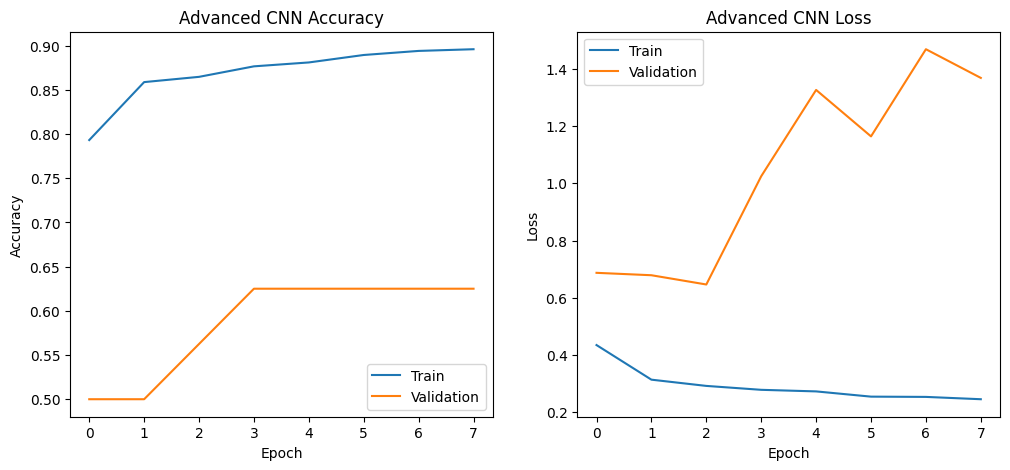

In [28]:
plot_history(
    history_advanced,
    "Advanced CNN"
)

In [29]:
# ======================================
# PREDICTIONS
# ======================================

y_true_adv = []
y_pred_adv = []

for images, labels in test_ds:

    predictions = advanced_model.predict(images)

    predictions = (predictions > 0.5).astype(int)

    y_true_adv.extend(labels.numpy())

    y_pred_adv.extend(predictions.flatten())

y_true_adv = np.array(y_true_adv)
y_pred_adv = np.array(y_pred_adv)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step


In [30]:
print(classification_report(

    y_true_adv,
    y_pred_adv,

    target_names=CLASS_NAMES

))

              precision    recall  f1-score   support

      NORMAL       0.46      0.99      0.63       234
   PNEUMONIA       0.98      0.31      0.47       390

    accuracy                           0.56       624
   macro avg       0.72      0.65      0.55       624
weighted avg       0.78      0.56      0.53       624



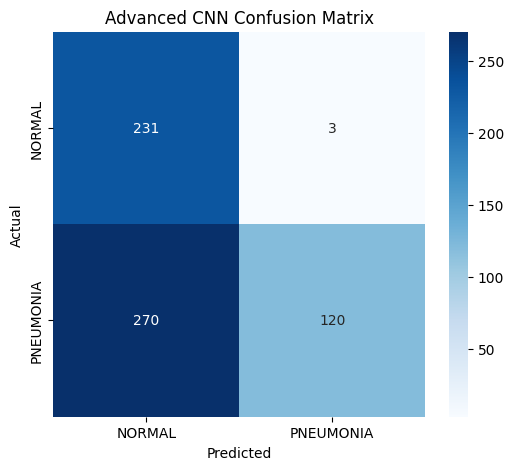

In [31]:
cm_adv = confusion_matrix(
    y_true_adv,
    y_pred_adv
)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm_adv,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES

)

plt.title("Advanced CNN Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


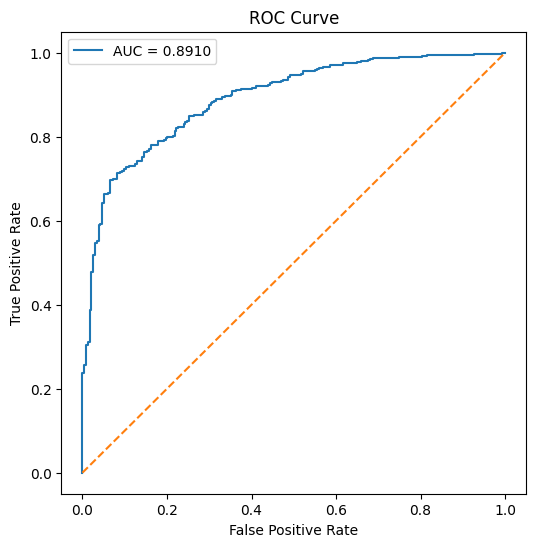

In [32]:
# ======================================
# PROBABILITY PREDICTIONS
# ======================================

y_probs = []

for images, labels in test_ds:

    predictions = advanced_model.predict(images)

    y_probs.extend(predictions.flatten())

y_probs = np.array(y_probs)

# ======================================
# ROC CURVE
# ======================================

fpr, tpr, thresholds = roc_curve(
    y_true_adv,
    y_probs
)

roc_auc = auc(fpr, tpr)

# ======================================
# PLOT ROC
# ======================================

plt.figure(figsize=(6,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [33]:
tf.keras.backend.clear_session()

gc.collect()

0

# 🌟 EfficientNetB0 Transfer Learning

EfficientNetB0 is a lightweight and highly optimized pretrained architecture.

Advantages:
- Faster training
- Lower memory usage
- Strong performance on medical imaging tasks

In [34]:
# ======================================
# LOAD PRETRAINED MODEL
# ======================================

base_transfer_model = EfficientNetB0(

    include_top=False,

    weights='imagenet',

    input_shape=(IMG_SIZE, IMG_SIZE, 3)

)

# ======================================
# FREEZE BASE MODEL
# ======================================

base_transfer_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [35]:
# ======================================
# TRANSFER LEARNING MODEL
# ======================================

transfer_model = Sequential([

    InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),

    data_augmentation,

    base_transfer_model,

    GlobalAveragePooling2D(),

    Dropout(0.4),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.3),

    Dense(
        1,
        activation='sigmoid',
        dtype='float32'
    )

])

transfer_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [36]:
transfer_model.compile(

    optimizer=Adam(
        learning_rate=1e-4
    ),

    loss='binary_crossentropy',

    metrics=[
        'accuracy'
    ]

)

In [37]:
history_transfer = transfer_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=10,

    callbacks=callbacks

)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 31s 109ms/step - accuracy: 0.8044 - loss: 0.4164 - val_accuracy: 0.8750 - val_loss: 0.3977 - learning_rate: 1.0000e-04
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.8823 - loss: 0.2700 - val_accuracy: 0.8750 - val_loss: 0.3936 - learning_rate: 1.0000e-04
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.8978 - loss: 0.2392 - val_accuracy: 0.8750 - val_loss: 0.3847 - learning_rate: 1.0000e-04
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.9034 - loss: 0.2198 - val_accuracy: 0.8750 - val_loss: 0.3942 - learning_rate: 1.0000e-04
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.9132 - loss: 0.2093 - val_accuracy: 0.8750 - val_loss: 0.3253 - learning_rate: 1.0000e-04
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.9128 - loss: 0.2055 - val_accuracy: 0.8750 - val_loss: 0.2505 - learning_rate: 1.0000e-04
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/st

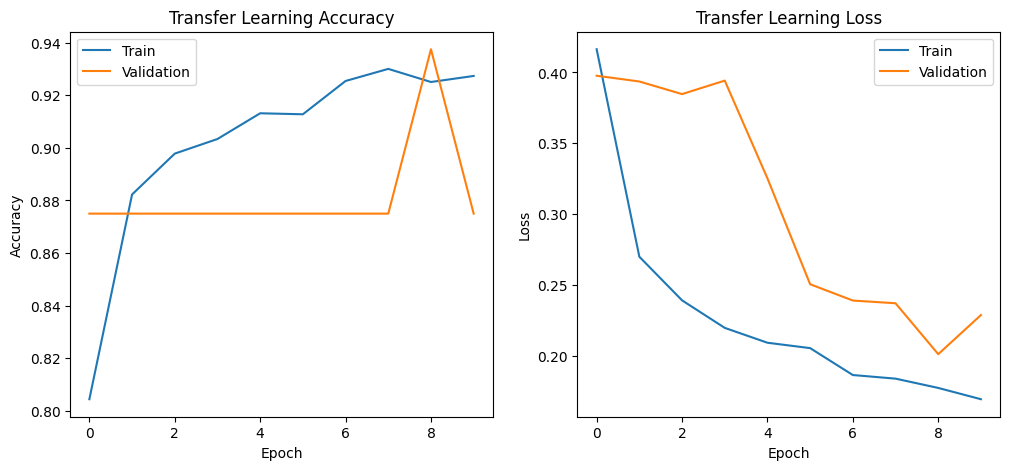

In [38]:
plot_history(
    history_transfer,
    "Transfer Learning"
)

In [39]:
y_true_transfer = []
y_pred_transfer = []

for images, labels in test_ds:

    predictions = transfer_model.predict(images)

    predictions = (predictions > 0.5).astype(int)

    y_true_transfer.extend(labels.numpy())

    y_pred_transfer.extend(predictions.flatten())

print(classification_report(

    y_true_transfer,
    y_pred_transfer,

    target_names=CLASS_NAMES

))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

      NORMAL       0.90      0.59      0.71       234
   PNEUMONIA       0.80      0.96      0.87       390

    accuracy                           0.82       624
   macro

In [40]:
# ======================================
# MODEL RESULTS
# ======================================

results = pd.DataFrame({

    "Model": [

        "Base CNN",

        "Advanced CNN",

        "Transfer Learning"

    ],

    "Accuracy": [

        max(history_base.history['val_accuracy']),

        max(history_advanced.history['val_accuracy']),

        max(history_transfer.history['val_accuracy'])

    ]

})

results

,Model,Accuracy
0,Base CNN,0.6250
1,Advanced CNN,0.6250
2,Transfer Learning,0.9375


In [62]:
# ======================================
# SAVE EFFICIENTNET MODEL
# ======================================

transfer_model.save(
    "efficientnet_chest_xray_model.keras"
)

print("EfficientNet Model Saved Successfully!")

EfficientNet Model Saved Successfully!


In [41]:
# ======================================
# CLEAR OLD MEMORY
# ======================================

tf.keras.backend.clear_session()

gc.collect()

0

# 🧠 ResNet50V2 Transfer Learning

ResNet50V2 is a deep residual network architecture.

Advantages:
- Powerful feature extraction
- Industry-level architecture
- Strong transfer learning capabilities

Disadvantages:
- Heavier than EfficientNet
- Slower training
- Higher VRAM usage

In [43]:
# ======================================
# LOAD PRETRAINED RESNET50V2
# ======================================

base_model = tf.keras.applications.ResNet50V2(

    input_shape=(IMG_SIZE, IMG_SIZE, 3),

    include_top=False,

    weights='imagenet'

)

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [46]:
# ======================================
# BUILD RESNET MODEL
# ======================================

resnet_model = tf.keras.models.Sequential([

    # INPUT LAYER
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # DATA AUGMENTATION
    data_augmentation,

    # NORMALIZATION
    tf.keras.layers.Rescaling(1./255),

    # PRETRAINED MODEL
    base_model,

    # FEATURE REDUCTION
    tf.keras.layers.GlobalAveragePooling2D(),

    # CLASSIFIER
    tf.keras.layers.Dense(
        256,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.4),

    # OUTPUT LAYER
    tf.keras.layers.Dense(
        1,
        activation='sigmoid',
        dtype='float32'
    )

])

resnet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,089,601 (91.89 MB)

 Trainable params: 24,044,161 (91.72 MB)

 Non-trainable params: 45,440 (177.50 KB)

In [47]:
# ======================================
# COMPILE MODEL
# ======================================

resnet_model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=LEARNING_RATE

    ),

    loss='binary_crossentropy',

    metrics=[

        'accuracy',

        tf.keras.metrics.Precision(name='precision'),

        tf.keras.metrics.Recall(name='recall')

    ]

)

In [48]:
# ======================================
# CLASS WEIGHTS
# ======================================

num_normal = len(

    os.listdir(

        os.path.join(train_path, 'NORMAL')

    )

)

num_pneumonia = len(

    os.listdir(

        os.path.join(train_path, 'PNEUMONIA')

    )

)

total = num_normal + num_pneumonia

# ======================================
# WEIGHT CALCULATION
# ======================================

weight_for_0 = (

    1 / num_normal

) * (total / 2.0)

weight_for_1 = (

    1 / num_pneumonia

) * (total / 2.0)

class_weights = {

    0: weight_for_0,

    1: weight_for_1

}

print(class_weights)

{0: 1.9448173005219984, 1: 0.6730322580645162}


In [50]:
# ======================================
# CALLBACKS
# ======================================

my_callbacks = [

    # EARLY STOPPING
    tf.keras.callbacks.EarlyStopping(

        monitor='val_loss',

        patience=5,

        restore_best_weights=True

    ),

    # SAVE BEST MODEL
    tf.keras.callbacks.ModelCheckpoint(

        filepath='best_resnet_model.keras',

        monitor='val_loss',

        save_best_only=True

    ),

    # REDUCE LEARNING RATE
    tf.keras.callbacks.ReduceLROnPlateau(

        monitor='val_loss',

        factor=0.2,

        patience=3,

        verbose=1

    )

]

In [51]:
# ======================================
# TRAINING
# ======================================

print("Training Started...")

history_resnet = resnet_model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    class_weight=class_weights,

    callbacks=my_callbacks

)

print("Training Completed!")

Training Started...
Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 462ms/step - accuracy: 0.9383 - loss: 0.1619 - precision: 0.9813 - recall: 0.9347 - val_accuracy: 0.5000 - val_loss: 3.1266 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 72s 442ms/step - accuracy: 0.9661 - loss: 0.0947 - precision: 0.9920 - recall: 0.9621 - val_accuracy: 0.8125 - val_loss: 0.6449 - val_precision: 0.7273 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 424ms/step - accuracy: 0.9714 - loss: 0.0855 - precision: 0.9913 - recall: 0.9701 - val_accuracy: 0.8125 - val_loss: 0.3915 - val_precision: 0.7273 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 67s 409ms/step - accuracy: 0.9758 - loss: 0.0597 - precision: 0.9942 - recall: 0.9732 - val_accuracy: 0.6875 - val_loss: 0.5871 - val_precision: 0.6154 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/20
163/

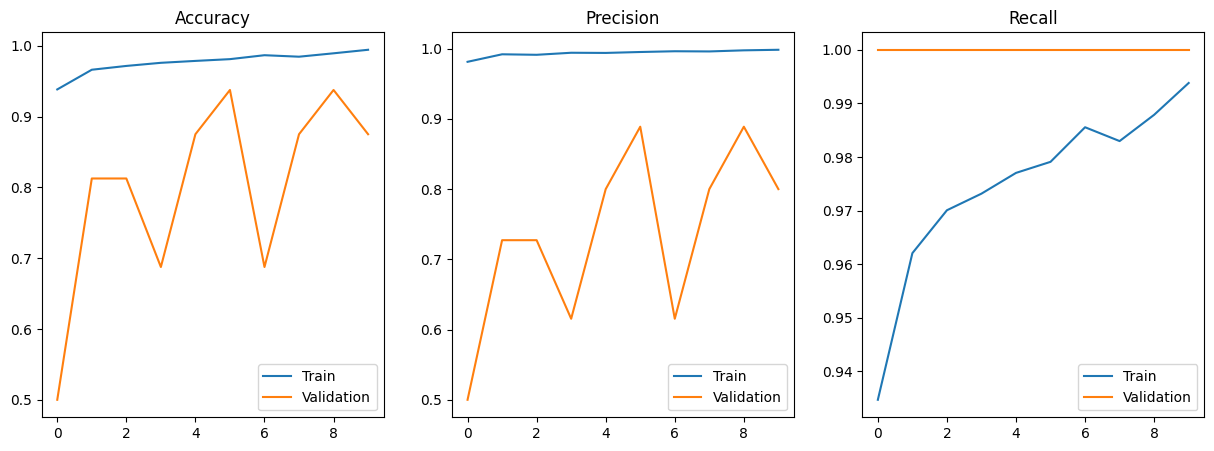

In [52]:
# ======================================
# ACCURACY
# ======================================

plt.figure(figsize=(15,5))

# ACCURACY
plt.subplot(1,3,1)

plt.plot(history_resnet.history['accuracy'])

plt.plot(history_resnet.history['val_accuracy'])

plt.title("Accuracy")

plt.legend(['Train','Validation'])

# PRECISION
plt.subplot(1,3,2)

plt.plot(history_resnet.history['precision'])

plt.plot(history_resnet.history['val_precision'])

plt.title("Precision")

plt.legend(['Train','Validation'])

# RECALL
plt.subplot(1,3,3)

plt.plot(history_resnet.history['recall'])

plt.plot(history_resnet.history['val_recall'])

plt.title("Recall")

plt.legend(['Train','Validation'])

plt.show()

In [53]:
# ======================================
# PREDICTIONS
# ======================================

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = resnet_model.predict(images)

    predictions = (predictions > 0.5).astype(int)

    y_true.extend(labels.numpy())

    y_pred.extend(predictions.flatten())

# ======================================
# CLASSIFICATION REPORT
# ======================================

print(classification_report(

    y_true,

    y_pred,

    target_names=CLASS_NAMES

))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

      NORMAL       0.93      0.88      0.91       234
   PNEUMONIA       0.93      0.96      0.95       390

    accuracy                           0.93       624
   macro

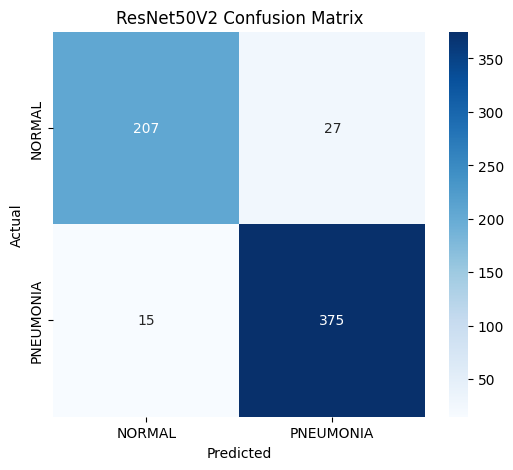

In [54]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("ResNet50V2 Confusion Matrix")

plt.show()

# 📊 Final Model Comparison

This section compares:
- Accuracy
- Precision
- Recall

across all trained models.

Goal:
Select the best-performing model objectively.

In [55]:
# ======================================
# FINAL METRICS
# ======================================

results = pd.DataFrame({

    "Model": [

        "Base CNN",

        "Advanced CNN",

        "EfficientNetB0",

        "ResNet50V2"

    ],

    "Best Validation Accuracy": [

        max(history_base.history['val_accuracy']),

        max(history_advanced.history['val_accuracy']),

        max(history_transfer.history['val_accuracy']),

        max(history_resnet.history['val_accuracy'])

    ],

    "Best Validation Precision": [

        max(history_base.history.get('val_precision', [0])),

        max(history_advanced.history.get('val_precision', [0])),

        max(history_transfer.history.get('val_precision', [0])),

        max(history_resnet.history.get('val_precision', [0]))

    ],

    "Best Validation Recall": [

        max(history_base.history.get('val_recall', [0])),

        max(history_advanced.history.get('val_recall', [0])),

        max(history_transfer.history.get('val_recall', [0])),

        max(history_resnet.history.get('val_recall', [0]))

    ]

})

# ======================================
# DISPLAY RESULTS
# ======================================

results

,Model,Best Validation Accuracy,Best Validation Precision,Best Validation Recall
0,Base CNN,0.6250,0.000000,0.0
1,Advanced CNN,0.6250,0.000000,0.0
2,EfficientNetB0,0.9375,0.000000,0.0
3,ResNet50V2,0.9375,0.888889,1.0


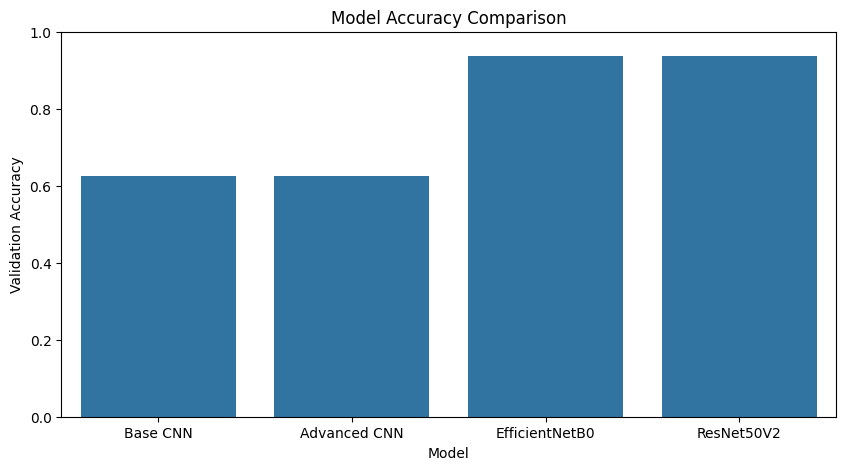

In [56]:
# ======================================
# ACCURACY COMPARISON
# ======================================

plt.figure(figsize=(10,5))

sns.barplot(

    data=results,

    x="Model",

    y="Best Validation Accuracy"

)

plt.title("Model Accuracy Comparison")

plt.ylabel("Validation Accuracy")

plt.ylim(0,1)

plt.show()

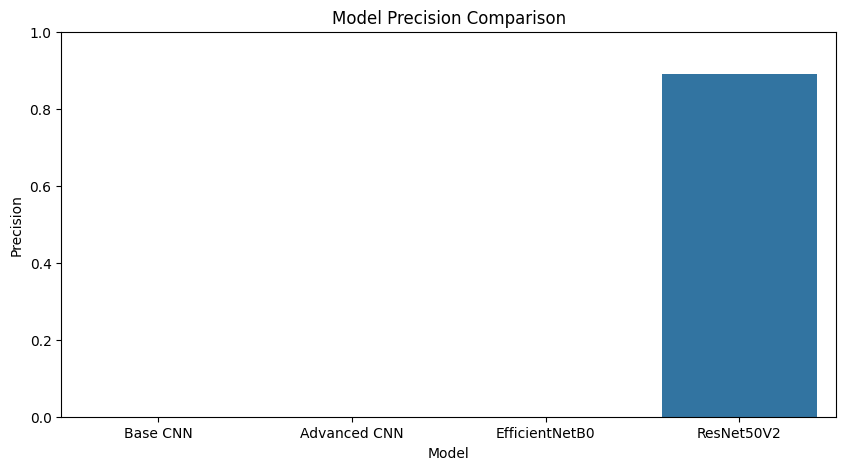

In [57]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=results,

    x="Model",

    y="Best Validation Precision"

)

plt.title("Model Precision Comparison")

plt.ylabel("Precision")

plt.ylim(0,1)

plt.show()

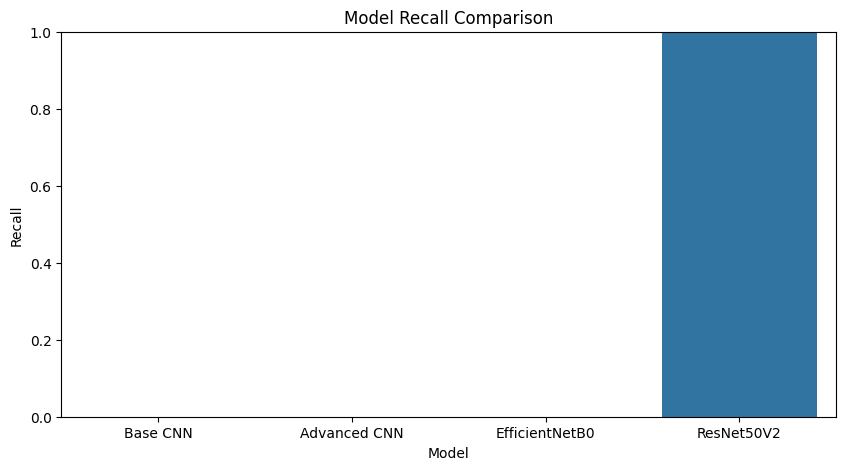

In [58]:
plt.figure(figsize=(10,5))

sns.barplot(

    data=results,

    x="Model",

    y="Best Validation Recall"

)

plt.title("Model Recall Comparison")

plt.ylabel("Recall")

plt.ylim(0,1)

plt.show()

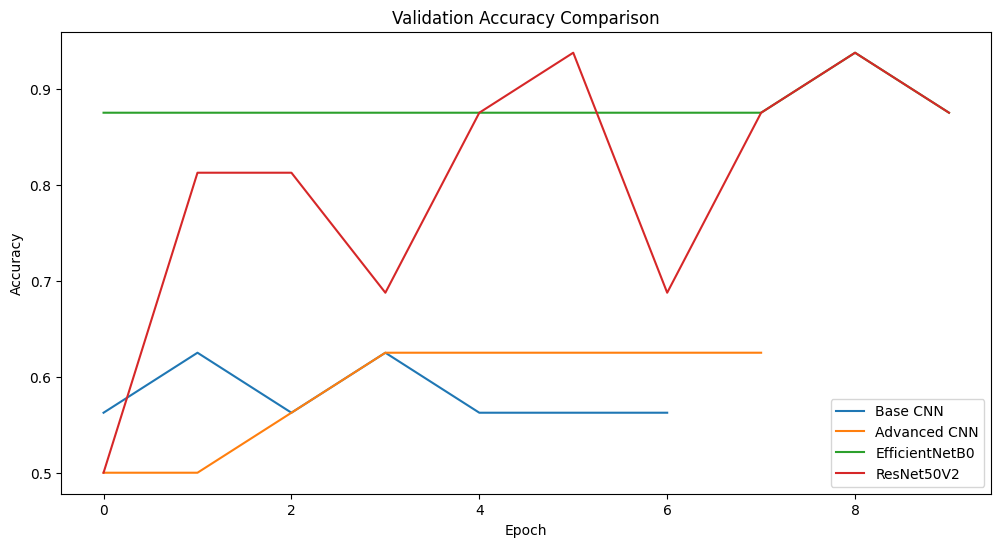

In [59]:
# ======================================
# COMPARE VALIDATION ACCURACY CURVES
# ======================================

plt.figure(figsize=(12,6))

plt.plot(
    history_base.history['val_accuracy'],
    label='Base CNN'
)

plt.plot(
    history_advanced.history['val_accuracy'],
    label='Advanced CNN'
)

plt.plot(
    history_transfer.history['val_accuracy'],
    label='EfficientNetB0'
)

plt.plot(
    history_resnet.history['val_accuracy'],
    label='ResNet50V2'
)

plt.title("Validation Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [60]:
# ======================================
# BEST MODEL
# ======================================

best_model_index = results[
    "Best Validation Accuracy"
].idxmax()

best_model_name = results.loc[
    best_model_index,
    "Model"
]

best_accuracy = results.loc[
    best_model_index,
    "Best Validation Accuracy"
]

print(f"Best Model: {best_model_name}")

print(f"Best Validation Accuracy: {best_accuracy:.4f}")

Best Model: EfficientNetB0
Best Validation Accuracy: 0.9375


# 📌 Final Conclusion

This project explored:
- CNN fundamentals
- Optimization techniques
- Transfer Learning
- Medical Image Classification

Multiple architectures were compared to identify the best-performing model for Chest X-Ray Pneumonia Detection.